# CSAI3121 - Machine Learning and Intelligent Data Analysis
## Lab 4 - Data Preprocessing

**Goal for today:** start with a messy dataset and build a preprocessing workflow that is ready for machine learning.

By the end of this lab, you should be able to:
1. Inspect missing values, duplicates, inconsistent categories, and suspicious numeric values.
2. Clean obvious data-quality problems.
3. Impute missing values.
4. Treat simple outliers.
5. Build a `ColumnTransformer` preprocessing pipeline without data leakage.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, RobustScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## Dataset

Run the next cell to create the raw dataset. Do not clean it yet.

In [51]:
data = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 8, 9, 10, 11],
    "Age": [22, 25, 29, 35, 42, 120, 31, np.nan, np.nan, 27, 39, 46],
    "Income": [25000, 28000, np.nan, 45000, 52000, 48000, 1000000, 38000, 38000, 32000, 58000, 61000],
    "Education": ["Bachelor", "Bachelor", "Master", "Master", "PhD", "High School", "Master", "Bachelor", "Bachelor", "High School", "Master", "PhD"],
    "City": ["Macao", "Macau", np.nan, "Hong Kong", "Zhuhai", "Zhuhai", "Macao", "Macao", "Macao", "Macau", "Hong Kong", "Zhuhai"],
    "Purchased": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "No", "No", "Yes", "Yes"],
}

raw_df = pd.DataFrame(data)
raw_df


,ID,Age,Income,Education,City,Purchased
0,1,22.000,"25,000.000",Bachelor,Macao,No
1,2,25.000,"28,000.000",Bachelor,Macau,No
2,3,29.000,NaN,Master,NaN,Yes
3,4,35.000,"45,000.000",Master,Hong Kong,Yes
4,5,42.000,"52,000.000",PhD,Zhuhai,Yes
5,6,120.000,"48,000.000",High School,Zhuhai,No
6,7,31.000,"1,000,000.000",Master,Macao,Yes
7,8,NaN,"38,000.000",Bachelor,Macao,No
8,8,NaN,"38,000.000",Bachelor,Macao,No
9,9,27.000,"32,000.000",High School,Macau,No


## Task 1. Inspect Data-Quality Problems

Find missing values, duplicates, inconsistent city labels, and suspicious numerical values.

Useful methods: `info()`, `isna().sum()`, `duplicated().sum()`, `unique()`, and `describe()`.

In [52]:
# TODO: inspect the structure of the dataset
print(raw_df.info(), '\n')

# TODO: count missing values
print(raw_df.isna().sum(), '\n')

# TODO: count exact duplicate rows
print(raw_df.duplicated().sum(), '\n')

# TODO: inspect city labels
print(raw_df['City'].unique(), '\n')

# TODO: summarize Age and Income
print(raw_df[['Age', 'Income']].describe(), '\n')


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         12 non-null     int64  
 1   Age        10 non-null     float64
 2   Income     11 non-null     float64
 3   Education  12 non-null     str    
 4   City       11 non-null     str    
 5   Purchased  12 non-null     str    
dtypes: float64(2), int64(1), str(3)
memory usage: 708.0 bytes
None 

ID           0
Age          2
Income       1
Education    0
City         1
Purchased    0
dtype: int64 

1 

<StringArray>
['Macao', 'Macau', nan, 'Hong Kong', 'Zhuhai']
Length: 5, dtype: str 

          Age        Income
count  10.000        11.000
mean   41.600   129,545.455
std    28.598   288,935.413
min    22.000    25,000.000
25%    27.500    35,000.000
50%    33.000    45,000.000
75%    41.250    55,000.000
max   120.000 1,000,000.000 



### Checkpoint

- Which columns contain missing values?
- Is there an exact duplicate row?
- Are `Macao` and `Macau` the same category for this lab, i.e. inconsistent data?
- Which numerical values look suspicious or extreme?

## Task 2. Clean and Impute

Clean the easy problems first, inspect the results after every step:
1. Remove exact duplicates, try `drop_duplicates().reset_index(drop=True)`
2. Replace `Macau` to `Macao`, try `replace()`.
3. Impute missing `Age` and `Income` with the median.
4. Impute missing `City` with the most frequent value.

#### How to use SimpleImputer?
```python
myimputer = SimpleImputer(strategy="median")
 
df[["col1"]] = myimputer.fit_transform(df[["col1"]])
```
`strategy` includes "median", "mean", "most_frequent", "constant"

When only transform without fitting:
```python
df[["col1"]] = myimputer.transform(df[["col1"]])
```


In [53]:
clean_df = raw_df.copy()

# TODO: remove exact duplicate rows and reset the index
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# TODO: replace Macau to Macao
clean_df["City"] = clean_df["City"].replace("Macau", "Macao")

# TODO: impute Age and Income with the median, put your transformed result into clean_df
num_imputer = SimpleImputer(strategy="median")
clean_df[["Age", "Income"]] = num_imputer.fit_transform(clean_df[["Age", "Income"]])

# TODO: impute City with the most frequent value, put your transformed result into clean_df
city_imputer = SimpleImputer(strategy="most_frequent")
clean_df[["City"]] = city_imputer.fit_transform(clean_df[["City"]])

clean_df

,ID,Age,Income,Education,City,Purchased
0,1,22.000,"25,000.000",Bachelor,Macao,No
1,2,25.000,"28,000.000",Bachelor,Macao,No
2,3,29.000,"46,500.000",Master,Macao,Yes
3,4,35.000,"45,000.000",Master,Hong Kong,Yes
4,5,42.000,"52,000.000",PhD,Zhuhai,Yes
5,6,120.000,"48,000.000",High School,Zhuhai,No
6,7,31.000,"1,000,000.000",Master,Macao,Yes
7,8,33.000,"38,000.000",Bachelor,Macao,No
8,9,27.000,"32,000.000",High School,Macao,No
9,10,39.000,"58,000.000",Master,Hong Kong,Yes


### Checkpoint

Confirm that there are no missing values left in `Age`, `Income`, or `City`.

In [54]:
# TODO: verify missing values after cleaning and imputation
clean_df.isna().sum()


ID           0
Age          0
Income       0
Education    0
City         0
Purchased    0
dtype: int64

## Task 3. Detect and Treat Outliers

Use the IQR rule to flag potential outliers in `Age` and `Income`.

Then apply these treatment choices for this lab:
- Treat `Age = 120` as an error and replace it with the median valid age.
- Treat `Income = 1,000,000` as a genuine but extreme value and cap it at the IQR upper bound.

In [55]:
def iqr_report(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)].tolist()
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": lower, "Upper": upper, "Outliers": outliers}

# Create IQR reports for Age and Income
age_report = iqr_report(clean_df["Age"])
income_report = iqr_report(clean_df["Income"])

# Display the reports as a DataFrame
outlier_report = pd.DataFrame([age_report, income_report], index=["Age", "Income"])
print(outlier_report, '\n')


valid_age = clean_df.loc[clean_df["Age"] <= age_report["Upper"], "Age"]
valid_age_median = valid_age.median()
clean_df.loc[clean_df["Age"] > age_report["Upper"], "Age"] = valid_age_median
print(clean_df["Age"], '\n')
print(clean_df["Age"].describe())

               Q1         Q3        IQR     Lower      Upper     Outliers
Age        28.000     40.500     12.500     9.250     59.250      [120.0]
Income 35,000.000 55,000.000 20,000.000 5,000.000 85,000.000  [1000000.0] 

0    22.000
1    25.000
2    29.000
3    35.000
4    42.000
5    32.000
6    31.000
7    33.000
8    27.000
9    39.000
10   46.000
Name: Age, dtype: float64 

count   11.000
mean    32.818
std      7.291
min     22.000
25%     28.000
50%     32.000
75%     37.000
max     46.000
Name: Age, dtype: float64


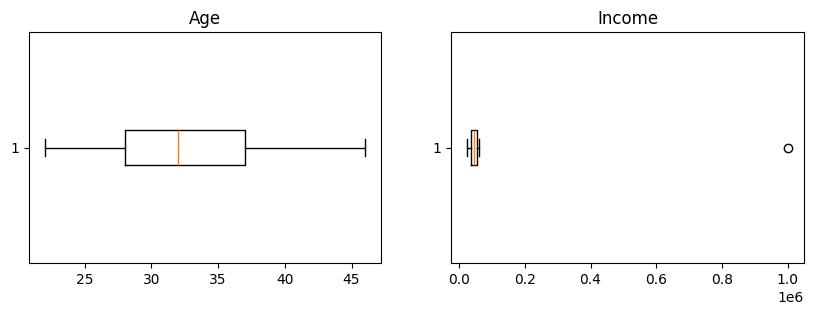

In [56]:
# Visual check
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].boxplot(clean_df["Age"], vert=False)
ax[0].set_title("Age")
ax[1].boxplot(clean_df["Income"], vert=False)
ax[1].set_title("Income")
plt.show()

# 箱子的长度就是 IQR，箱子两端的线条就是 Q1 和 Q3，箱子外的点就是异常值。
# 箱子中间的线条就是中位数Median，箱子两端的线条延伸到 Q1 - 1.5 * IQR 和 Q3 + 1.5 * IQR 的位置，超过这个范围的点就是异常值。

In [57]:
clean_df

,ID,Age,Income,Education,City,Purchased
0,1,22.000,"25,000.000",Bachelor,Macao,No
1,2,25.000,"28,000.000",Bachelor,Macao,No
2,3,29.000,"46,500.000",Master,Macao,Yes
3,4,35.000,"45,000.000",Master,Hong Kong,Yes
4,5,42.000,"52,000.000",PhD,Zhuhai,Yes
5,6,32.000,"48,000.000",High School,Zhuhai,No
6,7,31.000,"1,000,000.000",Master,Macao,Yes
7,8,33.000,"38,000.000",Bachelor,Macao,No
8,9,27.000,"32,000.000",High School,Macao,No
9,10,39.000,"58,000.000",Master,Hong Kong,Yes


In [58]:
treated_df = clean_df.copy()
# 我发现其实上面已经处理了 clean_df 中的 Age 和 Income 的异常值，所以 treated_df 其实 没发挥作用

# TODO: in treated_df, replace Age 120 with the median age among valid ages below 120
#       Obtain the median value, then replace it in the df. 
valid_age_median = treated_df.loc[treated_df["Age"] < 120, "Age"].median()
treated_df.loc[treated_df["Age"] == 120, "Age"] = valid_age_median

# TODO: in treated_df, cap Income at the IQR upper bound, use `clip()`
q1 = treated_df["Income"].quantile(0.25)
q3 = treated_df['Income'].quantile(0.75)
iqr = q3 - q1

income_upper = q3 + 1.5 * iqr
treated_df["Income_capped"] = treated_df["Income"].clip(upper=income_upper)

# TODO: in treated_df, create log(1 + Income) as another possible transformation, use `np.log1p()`
treated_df["Income_log"] = np.log1p(treated_df["Income"])

treated_df[["Age", "Income", "Income_capped", "Income_log"]]


,Age,Income,Income_capped,Income_log
0,22.000,"25,000.000","25,000.000",10.127
1,25.000,"28,000.000","28,000.000",10.240
2,29.000,"46,500.000","46,500.000",10.747
3,35.000,"45,000.000","45,000.000",10.714
4,42.000,"52,000.000","52,000.000",10.859
5,32.000,"48,000.000","48,000.000",10.779
6,31.000,"1,000,000.000","85,000.000",13.816
7,33.000,"38,000.000","38,000.000",10.545
8,27.000,"32,000.000","32,000.000",10.374
9,39.000,"58,000.000","58,000.000",10.968


### Checkpoint

Why did we replace suspicious `Age`, but cap extreme `Income`?

## Task 4. Build a Combined Preprocessor

In real ML workflows, preprocessing should be fitted on training data only. A `ColumnTransformer` helps keep the steps organized.

For this lab, use:
- Median imputation and robust scaling for numerical features.
- Most-frequent imputation and one-hot encoding for `City`.
- Most-frequent imputation and ordinal encoding for `Education`.
- Exclude `ID`.
- Keep `Purchased` as the target.

In [59]:
X = raw_df.drop(columns=["ID", "Purchased"])
y = raw_df["Purchased"]

# In a real project, split into training and test sets before fitting the preprocessor.

numerical_features = ["Age", "Income"]
nominal_features = ["City"]
ordinal_features = ["Education"]
education_order = [["High School", "Bachelor", "Master", "PhD"]]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # TODO: add OneHotEncoder with handle_unknown="ignore" and sparse_output=False
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # TODO: add OrdinalEncoder using education_order
    ('ordinal', OrdinalEncoder(categories=education_order))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("city", nominal_pipeline, nominal_features),
    ("edu", ordinal_pipeline, ordinal_features),
], verbose_feature_names_out=False)

# # fit_transform X
# X_prepared = preprocessor.fit_transform(X)

# # convert the result to a DataFrame with feature names
# prepared_df = pd.DataFrame(X_prepared, columns=preprocessor.get_feature_names_out())
# prepared_df["Purchased"] = LabelEncoder().fit_transform(y)
# prepared_df


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)   # 用 transform 而不是 fit_transform，因为我们不希望在测试集上重新拟合预处理器, train的fit已经学到了规律。

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


print("X_train shape:")
print(X_train.shape)

print("X_train prepared:")
print(X_train_prepared)

print("X_test prepared:")
print(X_test_prepared)

print("y_train:")
print(y_train_encoded)

print("y_test:")
print(y_test_encoded)

X_train shape:
(9, 4)
X_train prepared:
[[ 0.         -0.60714286  0.          1.          0.          0.
   1.        ]
 [ 7.72727273  0.10714286  0.          0.          0.          1.
   0.        ]
 [-0.54545455  0.          0.          1.          0.          0.
   2.        ]
 [-0.90909091 -1.32142857  0.          0.          1.          0.
   1.        ]
 [ 1.          1.03571429  0.          0.          0.          1.
   3.        ]
 [ 0.63636364  0.39285714  0.          0.          0.          1.
   3.        ]
 [ 0.         -0.60714286  0.          1.          0.          0.
   1.        ]
 [ 0.         -0.10714286  1.          0.          0.          0.
   2.        ]
 [-0.36363636 68.10714286  0.          1.          0.          0.
   2.        ]]
X_test prepared:
[[ 0.36363636  0.82142857  1.          0.          0.          0.
   2.        ]
 [-0.72727273 -1.03571429  0.          0.          1.          0.
   0.        ]
 [-1.18181818 -1.53571429  0.          1.          

## Checkpoint

Answer these before leaving:
1. Why was the median used to impute Age and Income instead of the mean?
2. Why was City one-hot encoded, while Education was ordinally encoded?
3. What is the purpose of using a ColumnTransformer?
4. When should imputation, encoding, and scaling be fitted: before or after the train/test split?
